In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

# Baseline Figures Comparison

In [3]:
title = "4K Stage Thermal Breakdown for 10k qubits (KIDE)"

In [11]:
fridge = "kide"
amps  = ["hemt", "hemt-lp", "hemt-ulp", "sisv1", ]
wires = ["cu", "mn", "ybco"]


exp_name_path = {}
pq_dict = {}
for amp in amps:
    for wire in wires:
        exp = "ff-fc-delft-"+ amp + "_" + wire + "-" + fridge
        fname = PROJ_ROOT_PATH / "notebooks" / "experiments" / "solutions"/ fridge / amp / exp / f"{exp}.pkl"
        exp_name_path[exp] = fname
        
        pqfname =  PROJ_ROOT_PATH / "notebooks" / "experiments" / "solutions"/ fridge / amp / exp  / f"PQ_{exp}.pkl"
        df_pq =  pd.read_pickle(pqfname)
        pq_dict[exp] = df_pq.iloc[0].tolist()

# For sisv1_11w_mn
exp_name_path[f'ff-fc-delft-sisv1_11w_mn-{fridge}'] = pathlib.Path(f'/repos/thermal_scalability/notebooks/experiments/solutions/{fridge}/sisv1/ff-fc-delft-sisv1_11w_mn-{fridge}/ff-fc-delft-sisv1_11w_mn-{fridge}.pkl')

pqfname =  pathlib.Path(f'/repos/thermal_scalability/notebooks/experiments/solutions/{fridge}/sisv1/ff-fc-delft-sisv1_11w_mn-{fridge}/PQ_ff-fc-delft-sisv1_11w_mn-{fridge}.pkl')
df_pq =  pd.read_pickle(pqfname)
pq_dict[f'ff-fc-delft-sisv1_11w_mn-{fridge}'] = df_pq.iloc[0].tolist()

 # [print(f"'{exp_name}':") for exp_name in exp_name_path.keys()]

xlabels_dict = {
    f'ff-fc-delft-hemt_cu-{fridge}': 'LNF8G(Cu)',
    f'ff-fc-delft-hemt_mn-{fridge}': 'LNF8G(Mn)',
    f'ff-fc-delft-hemt_ybco-{fridge}': 'LNF8G(YBCO)',
    f'ff-fc-delft-hemt-lp_cu-{fridge}': 'LNF8G-LP(Cu)',
    f'ff-fc-delft-hemt-lp_mn-{fridge}': 'LNF8G-LP(Mn)',
    f'ff-fc-delft-hemt-lp_ybco-{fridge}': 'LNF8G-LP(YBCO)',
    f'ff-fc-delft-hemt-ulp_cu-{fridge}': 'ULP-HEMT(Cu)',
    f'ff-fc-delft-hemt-ulp_mn-{fridge}': 'ULP-HEMT(Mn)',
    f'ff-fc-delft-hemt-ulp_ybco-{fridge}': 'ULP-HEMT(YBCO)',
    f'ff-fc-delft-sisv1_cu-{fridge}': 'SIS(Cu)',
    f'ff-fc-delft-sisv1_mn-{fridge}':'SIS(Mn)',
    f'ff-fc-delft-sisv1_ybco-{fridge}': 'SIS(YBCO)',
    f'ff-fc-delft-sisv1_11w_mn-{fridge}':'SIS-11w(Mn)',
}

In [12]:
print(xlabels_dict.keys())

dict_keys(['ff-fc-delft-hemt_cu-kide', 'ff-fc-delft-hemt_mn-kide', 'ff-fc-delft-hemt_ybco-kide', 'ff-fc-delft-hemt-lp_cu-kide', 'ff-fc-delft-hemt-lp_mn-kide', 'ff-fc-delft-hemt-lp_ybco-kide', 'ff-fc-delft-hemt-ulp_cu-kide', 'ff-fc-delft-hemt-ulp_mn-kide', 'ff-fc-delft-hemt-ulp_ybco-kide', 'ff-fc-delft-sisv1_cu-kide', 'ff-fc-delft-sisv1_mn-kide', 'ff-fc-delft-sisv1_ybco-kide', 'ff-fc-delft-sisv1_11w_mn-kide'])


In [13]:
# Experiment to plot
exp_list = [
    f'ff-fc-delft-hemt_cu-{fridge}', 
    f'ff-fc-delft-hemt_mn-{fridge}', 
    f'ff-fc-delft-hemt_ybco-{fridge}', 
    f'ff-fc-delft-hemt-lp_cu-{fridge}', 
    f'ff-fc-delft-hemt-lp_mn-{fridge}', 
    f'ff-fc-delft-hemt-lp_ybco-{fridge}', 
    f'ff-fc-delft-hemt-ulp_cu-{fridge}', 
    f'ff-fc-delft-hemt-ulp_mn-{fridge}', 
    f'ff-fc-delft-hemt-ulp_ybco-{fridge}', 
    f'ff-fc-delft-sisv1_cu-{fridge}', 
    f'ff-fc-delft-sisv1_mn-{fridge}', 
    f'ff-fc-delft-sisv1_ybco-{fridge}',
    f'ff-fc-delft-sisv1_11w_mn-{fridge}',
]

In [14]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
cooling_power_budget = FRIDGE_LIBRARY["XLD1000SL_v3"]
cooling_power_4K = cooling_power_budget["4K"]


ORG_NO_OF_PQ = 10_000
pq_number = 10_000

In [15]:
# Create Dataframes with experiments to plot
rows_4K = []
possible_physical_qubits = []
for exp_name in exp_list:
    # Get file path
    file_path = exp_name_path[exp_name]
    # Read dataframe
    df_data = pd.read_pickle(file_path)
    df = df_data.drop(columns=["Total"]).copy()
    # Extract only the values for 4K
    # rows_4K.append(df.loc["4K"])
    rows_4K.append(df.loc["4K"]*cooling_power_4K/ORG_NO_OF_PQ*pq_number)


    possible_physical_qubits.append(pq_dict[exp_name][1])

df_4K = pd.DataFrame(rows_4K, index=exp_list).fillna(0)

# 1) Decide the plotting order of stacks (columns)
# Reorder columns: PASSIVE first
original_columns = df_4K.columns.tolist()
passive_cols = [col for col in df_4K.columns if col[1] == 'PASSIVE']
active_cols  = [col for col in df_4K.columns if col[1] != 'PASSIVE']
reordered_columns = passive_cols + active_cols

# Reorder df_plot accordingly
df_4K = df_4K[reordered_columns]
cols = list(df_4K.columns)

/tmp/ipykernel_123581/2282616792.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df_data.drop(columns=["Total"]).copy()
/tmp/ipykernel_123581/2282616792.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df_data.drop(columns=["Total"]).copy()
/tmp/ipykernel_123581/2282616792.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df_data.drop(columns=["Total"]).copy()
/tmp/ipykernel_123581/2282616792.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df_data.drop(columns=["Total"]).copy()
/tmp/ipykernel_123581/2282616792.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df_data.drop(columns=["Total"]).copy()
/tmp/ipykernel_123581/228

In [16]:
# Plot
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white' 
fallback_hatch = '//'  

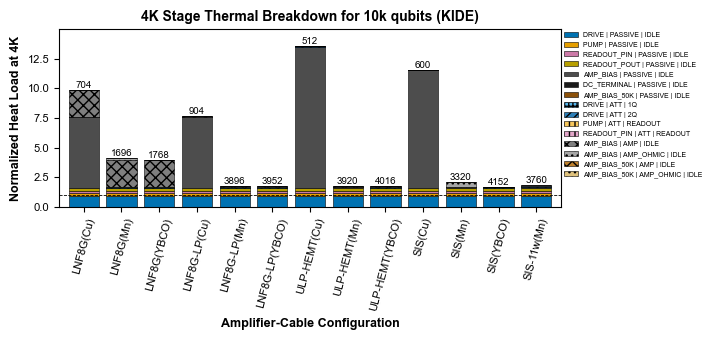

In [18]:
# 5) X positions and labels (temperature stages)
x = np.arange(len(df_4K.index))

xticklabels = []
for exp_name in exp_list:
    xticklabels.append(xlabels_dict[exp_name])

# 6) Create the figure/axes
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(figsize=(7.16, 3.5))

# 7) Build the stacked bars
bottom = np.zeros(len(x), dtype=float)

for i, col in enumerate(cols):
    values = df_4K[col].astype(float).values

    # pull style from style_map if present, else fallback
    style = style_map.get(col, {})
    color = style.get('color', fallback_color)
    hatch = style.get('hatch', fallback_hatch)

    # readable label in legend
    label = f"{col[0]} | {col[1]} | {col[2]}"

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor='black',
        linewidth=0.4
    )
    # apply hatch to each rectangle
    for b in bars:
        b.set_hatch(hatch)

    bottom += values  # update stack baseline

# Display no. of supported qubits on top of the bar
totals = df_4K .sum(axis=1)  # Sum over column. Get bar height
for i, total in enumerate(totals):
    ax.text(i, total, f'{possible_physical_qubits[i]}', ha='center', va='bottom', fontproperties=text_font)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)

# 8) Axis cosmetics
# Set titles 
ax.set_title(title, fontproperties=title_font)
ax.set_xlabel("Amplifier-Cable Configuration", fontproperties=axis_label_font)
ax.set_ylabel("Normalized Heat Load at 4K", fontproperties=axis_label_font)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=75)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_ylim(0, max(totals) * 1.1) # Set max y-value to be slightly higher than the tallest bar

# 9) Legend: shrink and place outside
ax.legend(ncol=1, 
          bbox_to_anchor=(1 ,1),
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.margins(x=0.02)
plt.tight_layout()
plt.savefig(f"./amp_heat_4K.png",dpi=600)
plt.show()